# import

In [1]:
import pandas as pd
import os
import datetime
from datetime import datetime
from datetime import timedelta

import numpy as np
import glob
import json
import random
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import Pool
import time
import gc
import math


from random import sample
# import plotnine
# from plotnine import *
# import Image
from PIL import Image

from pandarallel import pandarallel


#import yqg_common as yqg
import csv
# import setproctitle
# from impala.dbapi import connect
import sys
import copy


from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
from lightgbm import log_evaluation, early_stopping

from collections import Counter
from collections import defaultdict
from sklearn import metrics
# from sklearn import metrics.roc_auc_score
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn import preprocessing
from sklearn.metrics import roc_curve, auc

pd.set_option('display.max_rows', 10000)
pd.set_option('display.max_columns', 10000)
pd.set_option('display.width', 10000)
pd.set_option("max_colwidth", 10000)


# parallel
# from pandarallel import pandarallel
# pandarallel.initialize()

import warnings 
warnings.filterwarnings('ignore')

def auc_and_ks(results, model_score_column, label):
    auc = metrics.roc_auc_score(results[label], results[model_score_column])
    
    return auc

import matplotlib.font_manager as fm
 
myfont = fm.FontProperties(fname='/data1/mex_reloan_data/SimHei.ttf',size=15) 

# import sys
sys.path.append('/data1/mex_reloan_data/code_')  # 将package所在目录加入执行目录列表
import modelEvaluation
import psiCalculation
import modelEvaluation2

# 评估字段明细说明

## 业务字段和label

In [ ]:
'''
评估字段说明：
trace_id                                     trace_id(复贷一次风控)
loan_account_id                              用户ID
trace_ts                                     trace创建时刻
trace_date                                   trace创建日期
trace_end_ts                                 trace风控结束时刻
trace_end_date                               trace风控结束日期
risk_type                                    trace类型(C: 结清复贷; F：复贷续借; J:首贷续借; U:循环贷; L: 打款成功的额度测算)
risk_type_name                               trace类型名称
approve                                      一次风控是否通过
bf_max_overdue_days                          风控时刻用户历史逾期最大天数
bf_loan_times                                风控时刻贷款次数
bf_inloan_order_cnt                          风控时刻在贷笔数
bf_latest_payout_order_paid_terms            风控时刻最近一笔成功放款订单已还期数
bf_credit                                    风控前授信额度
af_credit                                    风控后授信额度
is_order                                     trace有效期内是否下单                                     
is_1d_order                                  一次风控后1天内是否下单                                 
is_3d_order                                  一次风控后3天内是否下单                                
is_7d_order                                  一次风控后7天内是否下单                                   
is_payout                                    trace有效期内是否有成功放款
is_1d_payout                                 一次风控后1天内是否成功放款                                   
is_3d_payout                                 一次风控后3天内是否成功放款                                 
is_7d_payout                                 一次风控后7天内是否成功放款                                  
first_order_principal                         风控后首个订单借款金额
first_order_credit                            风控后首个订单借款时可借额度
first_payout_order_id                         风控后首个成功放款订单ID
first_payout_order_principal                  风控后首个成功放款订单借款金额
first_payout_order_credit                     风控后首个成功放款订单借款时可借额度
trace_month                                   trace创建月份
trace_halfmonth                               按照OOT最早日期，每15天划分为一个半月，例如[2025-06-01,2025-06-16)
trace_week                                    按照OOT最早日期，每7天划分为一周，例如[2025-06-01,2025-06-08)    
first_order_credit_usage_rate                 风控后首个订单的额度使用率
first_payout_credit_usage_rate                风控后首个成功放款订单的额度使用率

current_payout_order_id                       trace对应的首笔放款订单（本笔订单）order_id
current_payout_order_ts                       trace对应的首笔放款订单（本笔订单），创建时间戳
current_payout_order_date                     trace对应的首笔放款订单（本笔订单），创建日期（统一用墨西哥日期）
current_payout_order_payout_ts                trace对应的首笔放款订单（本笔订单），放款时间戳
current_payout_order_payout_date              trace对应的首笔放款订单（本笔订单），放款期日
current_to_tracedate_delta_days               当前日期（统一用墨西哥日期）距trace天数
current_payout_order_seq                      trace对应的首笔放款订单（本笔订单），order_seq
current_payout_order_principal                trace对应的首笔放款订单（本笔订单），订单本金
current_payout_order_terms                    trace对应的首笔放款订单（本笔订单），订单期数
current_payout_order_billing_ts               trace对应的首笔放款订单（本笔订单），订单到期时间戳
current_payout_order_completed_ts             trace对应的首笔放款订单（本笔订单），订单完成时间戳
current_index{i}_days_diff                    当前距本笔订单的第{i}笔账单到期日的天数，i = 1~24。账单到期日在过去，正数；账单到期日在未来，负数；无此期账单，null
current_index{i}_overdue_days                 本笔订单，第{i}笔账单最大逾期天数，i = 1~24。提前结清账单（观测时点已结清，账单可能到期也可能没到期），此字段为负数；未到期且未提前结清的账单，此字段为null
current_payout_order_index_billing_list       本笔订单，账单到期时间戳序列，按逗号分隔
current_payout_order_index_completed_list     本笔订单，账单结清时间戳序列，按逗号分隔
rest_order_cnt                                trace#t1时刻在贷订单数
rest_instalment_cnt                           trace#t1时刻在贷账单数
rest_periods{i}_cnt                           trace#t1时刻在贷账单，trace后第{i}个周期的内的到期账单数（15天为一个周期），i = 1~24
rest_periods{i}_max_overdue_days              trace#t1时刻在贷账单，trace后第{i}个周期的内的到期账单（15天为一个周期）最大逾期天数。若为null，则账单还未到可观测周期；若为负数，则是提前还款
rest_periods1_{i}_overdue7                    trace#t1时刻在贷账单，trace后第1-{i}个周期的内的到期账单（15天为一个周期），其中任意一期触发7天逾期。若为null，则周期内的账单未全部满足观测期表现
rest_overdue{i}                               trace#t1时刻在贷账单，截止目前到期的账单，其中任意一期触发{i}天逾期，i = 1、3、7、15、31。若订单没有一个账单到期且满足{i}天观测，则为null；若任意一个账单到期且满足{i}天观测，则有值；即至少满足一期{i}天观测
rest_t0_unpaid_principal                      trace#t1时刻在贷本金
rest_t{i}_dpd7_unpaid_principal               trace#t1时刻在贷账单，trace后第1-{i}个周期的内的到期账单（15天为一个周期），在第{i}个周期+7天的日期存在逾期，则将那日期的各订单（在贷订单）的剩余未还本金作为坏账，i = 1~24。若为null，则周期内没有到期账单
all_periods{i}_cnt                            trace#t1时刻在贷账单+本笔订单，trace后第{i}个周期的内的到期账单数（15天为一个周期），i = 1~24
all_periods{i}_max_overdue_days               trace#t1时刻在贷账单+本笔订单，trace后第{i}个周期的内的到期账单（15天为一个周期）最大逾期天数，i = 1~24。若为null，则账单还未到可观测周期；若为负数，则是提前还款



-----  以下4种字段为本笔订单 人头风险常用label  ------------------------------------------------------
1pd{i}                                        本笔订单，第1期账单是否触发{i}天逾期，i = 1、3、7、15、31。若账单不满足观测期，则为null
{i}pd7                                        （最常用评估风险标签）本笔订单，第{i}期账单是否触发7天逾期，i = 2~24。若订单期数<{i}，则{i}pd7观测的是index最大的账单，是否在第{i}期到期后存在7天逾期（订单均扩展到24期）；若账单不满足观测期，则为null
current_{i}overdue7                           本笔订单，前{i}笔账单，是否任意期触发过7天逾期，i = 1~24。若订单的期数<{i}   或 第{i}笔账单不满足表现期，则为null
current_overdue{i}                            本笔订单，所有账单，是否任意期触发过{i}天逾期，i = 1、3、7、15、31。若订单没有一个账单到期，则为null；若任意一个账单到期，则有值；即至少满足一期观测


-----  以下1种字段为本笔订单 金额风险常用label  ------------------------------------------------------
{i}pd7_unpaid                                 第{i}期逾期7天时的剩余未还本金，与{i}pd7一样订单均扩展到24期（7天逾期当天的还款算作剩余未还，与策略保持统一）。若为0，则账单没有触发7天预期；若为null，则账单还未到观测期



---  以下2种字段为本笔 + 在贷订单 人头风险常用label ----------------------------------------------------
all_periods1_{i}_overdue7                     trace#t1时刻在贷账单+本笔订单，trace后第1-{i}个周期的内的到期账单（15天为一个周期），其中任意一期触发7天逾期，i = 1~24。若为null，则周期内的账单未全部满足观测期表现
all_overdue{i}                                trace#t1时刻在贷账单+本笔订单，截止目前到期的账单，其中任意一期触发{i}天逾期，i = 1、3、7、15、31。若订单没有一个账单到期且满足{i}天观测，则为null；若任意一个账单到期且满足{i}天观测，则有值；即至少满足一期{i}天观测



---  以下2种字段为本笔 + 在贷订单 金额风险常用label ----------------------------------------------------
all_t0_unpaid_principal                       trace#t1时刻在贷本金+本笔订单本金
all_t1_dpd7_unpaid_principal                  trace#t1时刻在贷账单+本笔订单，trace后第1-1个周期的内的到期账单（15天为一个周期），在第1个周期+7天的日期存在逾期，则将那日期的各订单（在贷订单）的剩余未还本金作为坏账。若为null，则周期内没有到期账单
'''

## 模型字段

In [ ]:
'''
modelid_200000609  # 复贷主模型V6-短风险版 线上模型分
modelid_200000610  # 复贷主模型V6-长风险版 线上模型分
'''

# 获取评估数据

In [2]:
# 主模型V6 OOT s20250601_e20260228 全量样本
test_data = pd.read_parquet('/data1/mex_reloan_data/mex_reloan_trace_test_data_s20250601_e20260228_basicinfo_and_v6modelscore')
test_data.count()

trace_id                                     5273303
loan_account_id                              5273303
trace_ts                                     5273303
trace_date                                   5273303
trace_end_ts                                 5273303
trace_end_date                               5273303
risk_type                                    5273303
risk_type_name                               5273303
approve                                      5273303
bf_max_overdue_days                          5265142
bf_loan_times                                4308926
bf_inloan_order_cnt                          5270341
bf_latest_payout_order_paid_terms            5270094
bf_credit                                    5273302
af_credit                                    5273302
is_order                                     5273303
is_1d_order                                  5273303
is_3d_order                                  5273303
is_7d_order                                  5

## 关联新预估的模型分

In [3]:
model_and_feats_file = '/data1/mex_reloan_data/主模型V6/models_and_feats' # 模型和特征重要度文件存储路径  
save_path = '/data1/mex_reloan_data/主模型V6/test_prediction'  # 预估结果存储路径

for model in [
    'reloan_clear_model_v6_shortvintage_alldata_lgb_train',
    'reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w' # 模型名称

]:
    print(model)
    save_file_name = f'{save_path}/{model}_s2506_e2602_reloan_all_trace_prediction'
    pred = pd.read_parquet(save_file_name)
    test_data = pd.merge(test_data, pred, how = 'left', on = 'trace_id')
test_data.count()

reloan_clear_model_v6_shortvintage_alldata_lgb_train
reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w


trace_id                                                        5273303
loan_account_id                                                 5273303
trace_ts                                                        5273303
trace_date                                                      5273303
trace_end_ts                                                    5273303
trace_end_date                                                  5273303
risk_type                                                       5273303
risk_type_name                                                  5273303
approve                                                         5273303
bf_max_overdue_days                                             5265142
bf_loan_times                                                   4308926
bf_inloan_order_cnt                                             5270341
bf_latest_payout_order_paid_terms                               5270094
bf_credit                                                       

## 人群分组（主模型V6-长风险 训练集划分）

In [ ]:
# oot\boot\uoot\goot的划分逻辑：
# - oot – 训练时间外至模型上线前的所有线下测试样本
# - TrainBad – 训练样本中，存在label = 1样本的用户，这些用户在oot上的样本即为TrainBad；在当前的风控架构下，这些用户未来不能进行下单（当前，用户历史最大逾期天数<=7才能再来下单）
# - boot – oot中剔除TrainBad样本，剩下的样本即为boot，是模型上线后真正能服务的人群对应的样本；boot = uoot + goot
# - uoot – oot中训练集没见过的用户对应的样本
# - goot – oot中训练集见过的用户对应的样本，但这些用户在训练集中只有label = 0的样本，即模型仅见过他们’好‘的一面

In [4]:
# 主模型V6-长风险版 训练集
label_data = pd.read_parquet('/data1/mex_reloan_data/mex_reloan_trace_payout_test_data_s20230101_e20260217_v6features_label_basicinfo',
                      columns = ['trace_id', 
                                 'loan_account_id',
                                 'current_payout_order_payout_date',
                                 'current_456overdue7_ever'])
# 训练集切分
label_name = 'current_456overdue7_ever' # 训练标签
split_key = 'current_payout_order_payout_date' # 成功放款日期
split_start_date = '2024-01-01' # 训练集起始时间
split_end_date = '2025-05-31' # 训练集结束时间
label_data = label_data[(label_data[split_key] >= split_start_date) 
                    & (label_data[split_key] <= split_end_date) 
                     & (label_data[label_name] >= 0)]
print(label_data.shape)

label_data = label_data.astype({'loan_account_id': np.int64})
test_data = modelEvaluation.get_threeGroup_tag(
    test_data = test_data, # 评级样本
    train_data = label_data, # 训练集样本和label
    label = label_name, # 训练标签
    suffix = 'main_model_v6' # 给TrainBad,UOOT,GOOT,BOOT加上后缀，便于多个模型的人群的区分，若不要后缀，则用''
)
print(test_data.shape)

(1572813, 4)
(5273303, 385)


In [5]:
test_data.count()

trace_id                                                        5273303
loan_account_id                                                 5273303
trace_ts                                                        5273303
trace_date                                                      5273303
trace_end_ts                                                    5273303
trace_end_date                                                  5273303
risk_type                                                       5273303
risk_type_name                                                  5273303
approve                                                         5273303
bf_max_overdue_days                                             5265142
bf_loan_times                                                   4308926
bf_inloan_order_cnt                                             5270341
bf_latest_payout_order_paid_terms                               5270094
bf_credit                                                       

## save 读取原始评估数据，关联模型分，计算BOOT等标签后，重新存一份数据，避免操作失误修改了原始数据

In [6]:
# 示例，路径可以自行更改
test_data.to_parquet('/data1/mex_reloan_data/mex_reloan_trace_test_data_s20250601_e20260228_basicinfo_and_v6modelscore_foreval_20260318get')

# 评估报告

In [ ]:
'''
报告结构

1、模型相关性
- 1.1 一次风控（全量客群）
- 1.2 成功放款客群

2、AUC评估（风险标签1pd7、4pd7、6pd7）
- 2.1 成功放款客群：OOT:本笔label (新增风险)
- 2.2 成功放款客群：BOOT: 本笔label (新增风险)

3、人头逾期和金额逾期曲线
- 3.1 本笔订单人头逾期（term1、term4、term6）
- 3.2 本笔订单金额逾期（term1、term4、term6）

4、分bin-风险Lift和基础画像
- 4.1 成功放款客群 分bin-风险Lift和基础画像 - 6pd7长期风险标签

5、模型分布
- 5.1 全量客群模型分布-图示版
- 5.2 全量客群模型分布-分bin比例版

6、交叉评估heatmap
- 6.1 成功放款客群 逐月长短风险模型heatmap

'''

************************************************* 0 评估模型列表 ********************************************************
['modelid_200000609', 'modelid_200000610', 'reloan_clear_model_v6_shortvintage_alldata_lgb_train', 'reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w']


1、模型相关性
************************************************* 1.1 一次风控（全量客群）********************************************************


,modelid_200000609,modelid_200000610,reloan_clear_model_v6_shortvintage_alldata_lgb_train,reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w
modelid_200000609,1.000000,0.733873,0.832410,0.681672
modelid_200000610,0.733873,1.000000,0.834204,0.970510
reloan_clear_model_v6_shortvintage_alldata_lgb_train,0.832410,0.834204,1.000000,0.843984
reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w,0.681672,0.970510,0.843984,1.000000


************************************************* 1.2 成功放款客群  *************************************************************


,modelid_200000609,modelid_200000610,reloan_clear_model_v6_shortvintage_alldata_lgb_train,reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w
modelid_200000609,1.000000,0.733873,0.832410,0.681672
modelid_200000610,0.733873,1.000000,0.834204,0.970510
reloan_clear_model_v6_shortvintage_alldata_lgb_train,0.832410,0.834204,1.000000,0.843984
reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w,0.681672,0.970510,0.843984,1.000000




2、AUC
trace_month 时间分组

********************************************** 2.1 成功放款客群：OOT:本笔label (新增风险)***********************************************************
1pd7


...

4pd7


,trace_month,count,4pd7,modelid_200000609,modelid_200000610,reloan_clear_model_v6_shortvintage_alldata_lgb_train,reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w
0,2025-06,88478,0.115984,0.702304,0.714971,0.707143,0.716800
1,2025-07,105300,0.188680,0.686397,0.716885,0.689602,0.718055
2,2025-08,118682,0.215778,0.681678,0.712147,0.682287,0.713537
3,2025-09,125909,0.210612,0.681124,0.709099,0.680884,0.709430
4,2025-10,128720,0.187290,0.675912,0.708520,0.676087,0.709365
5,2025-11,133797,0.172784,0.667875,0.698465,0.670331,0.699683
6,2025-12,114897,0.195697,0.664898,0.690358,0.667242,0.691512
7,2026-01,7114,0.201855,0.659379,0.693481,0.660058,0.694544
8,total,822897,0.186419,0.678625,0.707626,0.680206,0.708704


6pd7


,trace_month,count,6pd7,modelid_200000609,modelid_200000610,reloan_clear_model_v6_shortvintage_alldata_lgb_train,reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w
0,2025-06,88377,0.184109,0.667928,0.704740,0.671248,0.705305
1,2025-07,105143,0.259437,0.658494,0.708439,0.660453,0.708586
2,2025-08,118508,0.282285,0.658055,0.707646,0.658069,0.708131
3,2025-09,125618,0.270606,0.659721,0.706987,0.659890,0.706695
4,2025-10,128046,0.250394,0.651663,0.703971,0.652327,0.704373
5,2025-11,126593,0.238852,0.645105,0.692769,0.646884,0.693310
6,2025-12,9275,0.265121,0.637974,0.681990,0.639031,0.681927
7,total,701560,0.250517,0.656220,0.704366,0.657356,0.704670




3、人头逾期和金额逾期曲线
********************************************** 3.1 本笔订单人头逾期（term1、term4、term6）***********************************************************


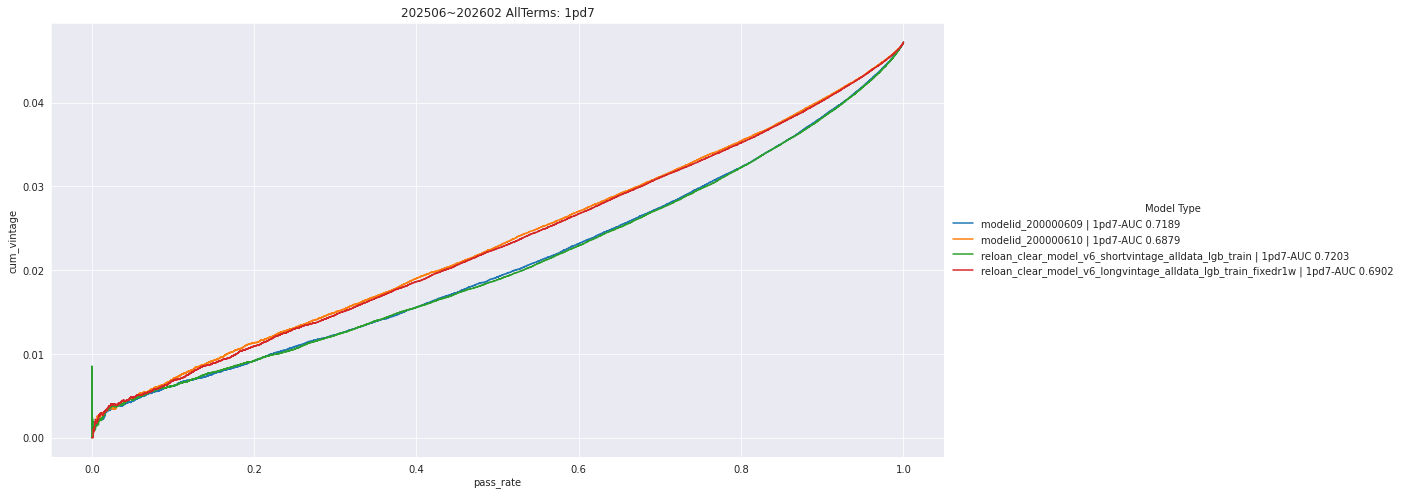

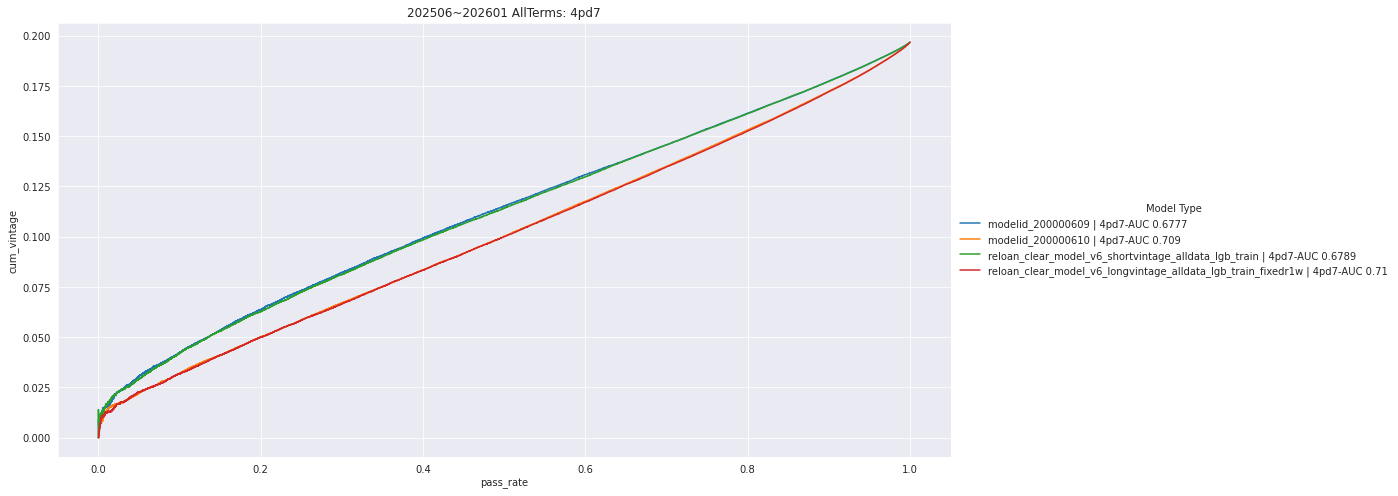

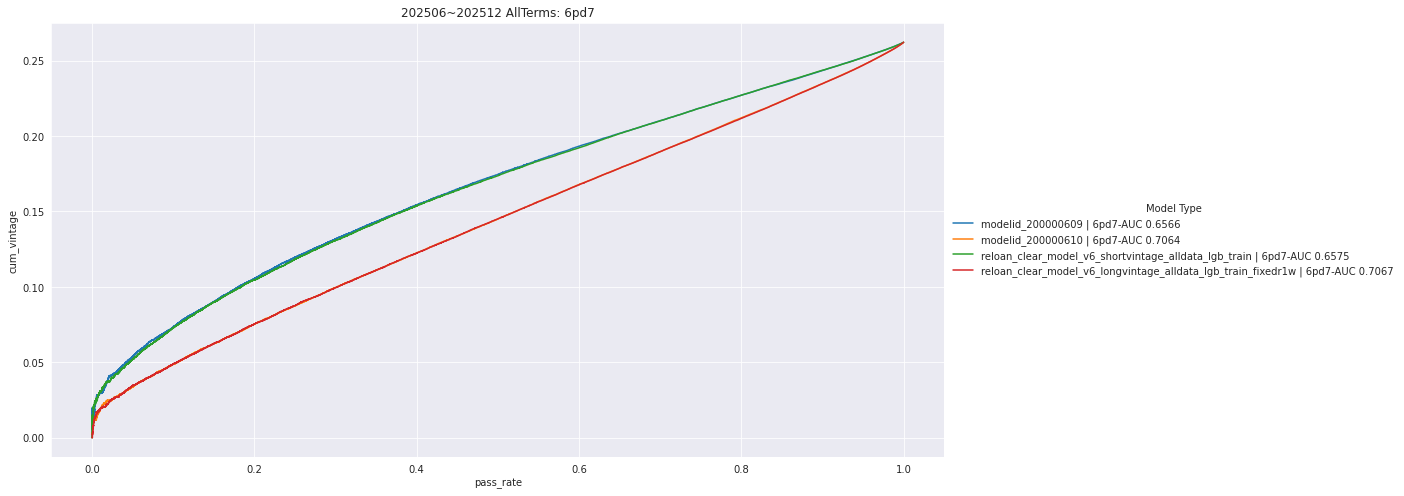


********************************************** 3.2 本笔订单金额逾期（term1、term4、term6）***********************************************************


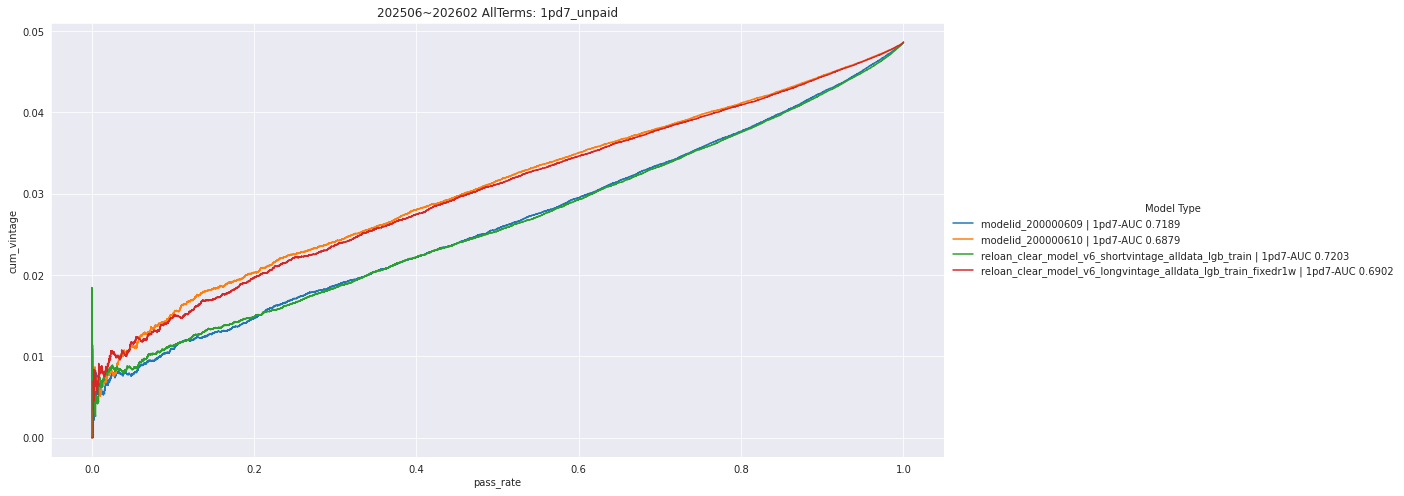

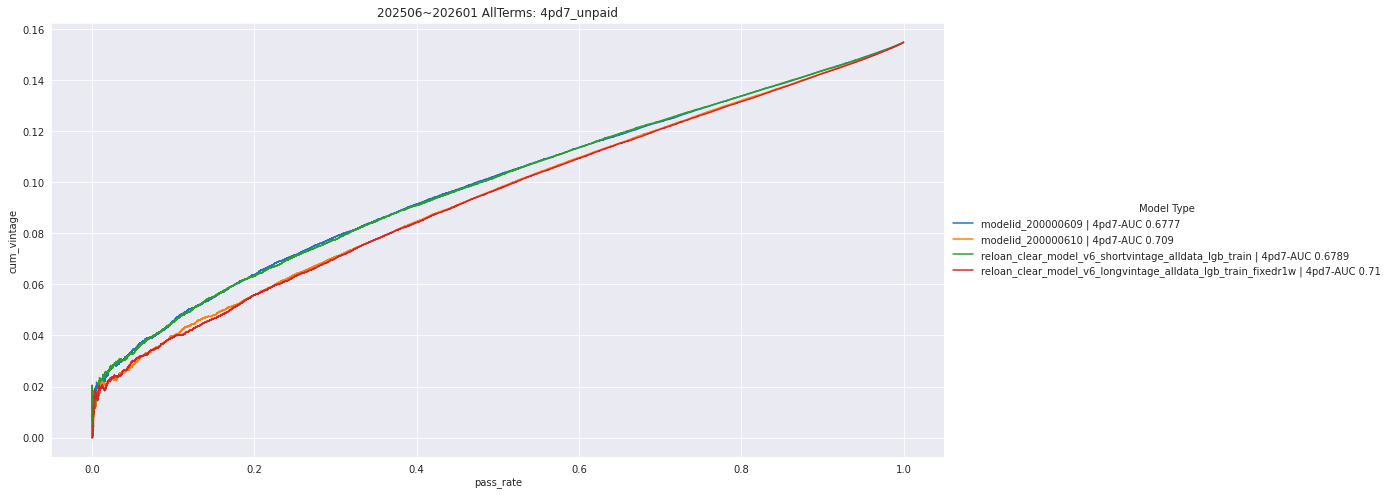

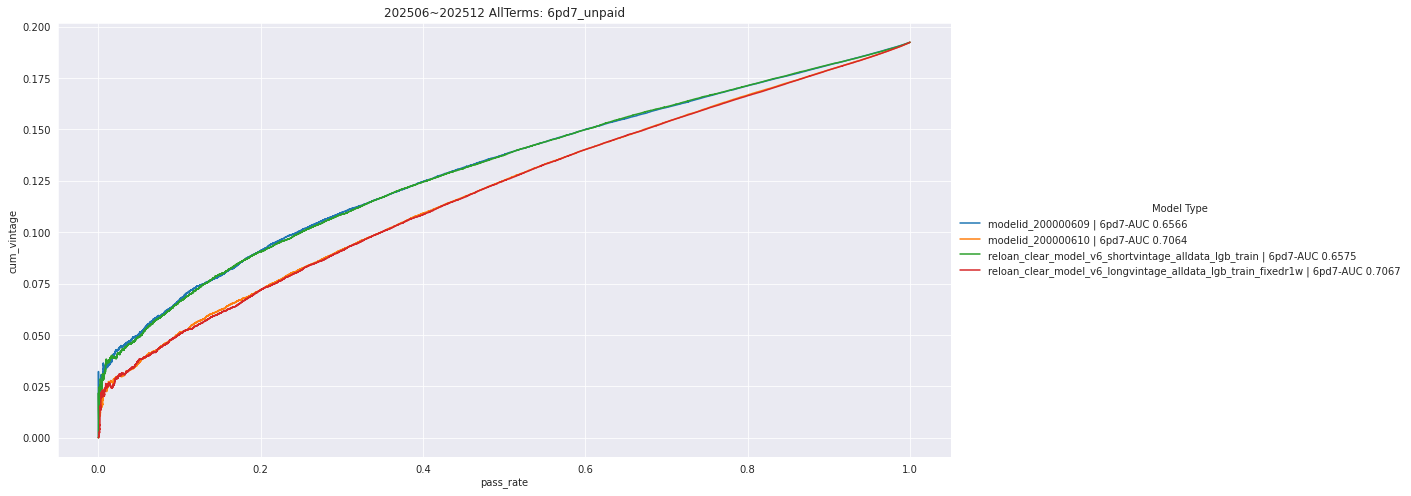



4、分bin-风险Lift和基础画像
********************************************** 4.1 成功放款客群 分bin-风险Lift和基础画像 - 6pd7长期风险标签 ***********************************************************
modelid_200000609


,bin,trace_id,current_payout_order_id,num_ratio,good_num,bad_num,bad_ratio,good_cumsum,bad_cumsum,ks,acc_auc,bin_auc,bin_lift,is_order,is_payout,first_order_credit_usage_rate,bf_credit,af_credit,bf_max_overdue_days,bf_loan_times,bf_inloan_order_cnt,bf_latest_payout_order_paid_terms
0,"(-0.0002, 0.0113]",71339,71339,0.100,66121,5218,0.0731,0.1256,0.0279,0.0977,0.5958,0.5958,0.279,1.0000,1.0000,0.234,38001,39544,0.2550,11.5214,3.0954,1.5053
1,"(0.0113, 0.0170]",71339,71339,0.100,61511,9828,0.1378,0.2425,0.0804,0.1620,0.6140,0.5356,0.525,1.0000,1.0000,0.327,32103,34242,0.2916,9.4374,2.7405,1.4357
2,"(0.0170, 0.0229]",71338,71338,0.100,58190,13148,0.1843,0.3530,0.1507,0.2023,0.6213,0.5197,0.703,1.0000,1.0000,0.409,27465,29720,0.2942,8.3136,2.4907,1.4569
3,"(0.0229, 0.0294]",71339,71339,0.100,55503,15836,0.2220,0.4585,0.2354,0.2231,0.6262,0.5192,0.847,1.0000,1.0000,0.483,23804,25908,0.2910,7.6921,2.3246,1.4726
4,"(0.0294, 0.0368]",71339,71339,0.100,53125,18214,0.2553,0.5594,0.3328,0.2266,0.6299,0.5117,0.974,1.0000,1.0000,0.545,20559,22393,0.2900,7.1530,2.1890,1.4899
5,"(0.0368, 0.0457]",71338,71338,0.100,50860,20478,0.2871,0.6560,0.4423,0.2137,0.6339,0.5122,1.095,1.0000,1.0000,0.604,17637,19253,0.2999,6.6032,2.0333,1.5232
6,"(0.0457, 0.0570]",71339,71339,0.100,49108,22231,0.3116,0.7493,0.5612,0.1882,0.6364,0.5133,1.189,1.0000,1.0000,0.657,15235,16508,0.3128,6.2271,1.9037,1.5114
7,"(0.0570, 0.0730]",71338,71338,0.100,46727,24611,0.3450,0.8381,0.6927,0.1454,0.6410,0.5114,1.316,1.0000,1.0000,0.704,12910,13865,0.3390,5.8006,1.7435,1.4976
8,"(0.0730, 0.1000]",71339,71339,0.100,44602,26737,0.3748,0.9228,0.8357,0.0871,0.6460,0.5140,1.430,1.0000,1.0000,0.750,10607,11266,0.3793,5.3740,1.5498,1.4338
9,"(0.1000, 0.6980]",71339,71339,0.100,40610,30729,0.4307,1.0000,1.0000,0.0000,0.6566,0.5327,1.643,1.0000,1.0000,0.792,8091,8371,0.4878,4.8661,1.2890,1.3442


modelid_200000610


,bin,trace_id,current_payout_order_id,num_ratio,good_num,bad_num,bad_ratio,good_cumsum,bad_cumsum,ks,acc_auc,bin_auc,bin_lift,is_order,is_payout,first_order_credit_usage_rate,bf_credit,af_credit,bf_max_overdue_days,bf_loan_times,bf_inloan_order_cnt,bf_latest_payout_order_paid_terms
0,"(0.0037, 0.0850]",71339,71339,0.100,67873,3466,0.0486,0.1289,0.0185,0.1104,0.6071,0.6071,0.185,1.0000,1.0000,0.200,38238,39149,0.3963,12.6576,2.5456,1.4904
1,"(0.0850, 0.1300]",71339,71339,0.100,64073,7266,0.1019,0.2507,0.0574,0.1933,0.6283,0.5451,0.389,1.0000,1.0000,0.303,32667,34650,0.4469,10.1159,2.4206,1.4180
2,"(0.1300, 0.1730]",71338,71338,0.100,60768,10570,0.1482,0.3661,0.1139,0.2522,0.6396,0.5312,0.565,1.0000,1.0000,0.392,27612,30031,0.4119,8.9345,2.2767,1.4120
3,"(0.1730, 0.2160]",71339,71339,0.100,57664,13675,0.1917,0.4757,0.1870,0.2887,0.6481,0.5260,0.731,1.0000,1.0000,0.470,23153,25614,0.3767,7.7853,2.1401,1.4146
4,"(0.2160, 0.2590]",71339,71339,0.100,54616,16723,0.2344,0.5794,0.2764,0.3030,0.6557,0.5212,0.894,1.0000,1.0000,0.545,19703,21867,0.3432,7.0780,2.0782,1.4399
5,"(0.2590, 0.3040]",71338,71338,0.100,51231,20107,0.2819,0.6768,0.3839,0.2928,0.6647,0.5165,1.075,1.0000,1.0000,0.613,16754,18528,0.3069,6.3923,2.0101,1.4378
6,"(0.3040, 0.3530]",71339,71339,0.100,48475,22864,0.3205,0.7689,0.5062,0.2627,0.6713,0.5163,1.222,1.0000,1.0000,0.673,14664,15991,0.2868,5.8090,1.9852,1.4333
7,"(0.3530, 0.4100]",71338,71338,0.100,45003,26335,0.3692,0.8544,0.6470,0.2074,0.6797,0.5160,1.408,1.0000,1.0000,0.725,12740,13687,0.2558,5.3682,1.9625,1.4518
8,"(0.4100, 0.4880]",71339,71339,0.100,41630,29709,0.4164,0.9335,0.8058,0.1276,0.6886,0.5204,1.589,1.0000,1.0000,0.770,11160,11730,0.2327,4.9771,1.9561,1.4990
9,"(0.4880, 0.8900]",71339,71339,0.100,35024,36315,0.5090,1.0000,1.0000,0.0000,0.7064,0.5565,1.942,1.0000,1.0000,0.814,9720,9823,0.1834,4.5506,1.9940,1.6746


reloan_clear_model_v6_shortvintage_alldata_lgb_train


,bin,trace_id,current_payout_order_id,num_ratio,good_num,bad_num,bad_ratio,good_cumsum,bad_cumsum,ks,acc_auc,bin_auc,bin_lift,is_order,is_payout,first_order_credit_usage_rate,bf_credit,af_credit,bf_max_overdue_days,bf_loan_times,bf_inloan_order_cnt,bf_latest_payout_order_paid_terms
0,"(0.0021, 0.1320]",71339,71339,0.100,66149,5190,0.0728,0.1257,0.0277,0.0979,0.6046,0.6046,0.278,1.0000,1.0000,0.233,38526,39942,0.2614,11.9745,3.1621,1.5259
1,"(0.1320, 0.1950]",71339,71339,0.100,61612,9727,0.1363,0.2427,0.0798,0.1630,0.6149,0.5355,0.520,1.0000,1.0000,0.326,32600,34695,0.3049,9.4983,2.7518,1.4357
2,"(0.1950, 0.2520]",71338,71338,0.100,58282,13056,0.1830,0.3535,0.1496,0.2039,0.6224,0.5244,0.698,1.0000,1.0000,0.404,27955,30190,0.3099,8.4218,2.5146,1.4619
3,"(0.2520, 0.3070]",71339,71339,0.100,55456,15883,0.2226,0.4588,0.2345,0.2243,0.6280,0.5195,0.849,1.0000,1.0000,0.477,23959,26105,0.2996,7.6815,2.3473,1.4818
4,"(0.3070, 0.3620]",71339,71339,0.100,53258,18081,0.2535,0.5600,0.3312,0.2288,0.6305,0.5119,0.967,1.0000,1.0000,0.541,20575,22475,0.2997,7.0290,2.1765,1.5021
5,"(0.3620, 0.4180]",71338,71338,0.100,51019,20319,0.2848,0.6569,0.4398,0.2171,0.6338,0.5073,1.086,1.0000,1.0000,0.604,17609,19205,0.3022,6.5009,2.0303,1.5067
6,"(0.4180, 0.4770]",71339,71339,0.100,48703,22636,0.3173,0.7495,0.5608,0.1886,0.6383,0.5064,1.210,1.0000,1.0000,0.661,14859,16174,0.3052,6.0095,1.8831,1.5210
7,"(0.4770, 0.5440]",71338,71338,0.100,46655,24683,0.3460,0.8381,0.6928,0.1453,0.6427,0.5105,1.320,1.0000,1.0000,0.710,12450,13419,0.3227,5.5243,1.7155,1.4962
8,"(0.5440, 0.6280]",71339,71339,0.100,44506,26833,0.3761,0.9226,0.8363,0.0864,0.6475,0.5111,1.435,1.0000,1.0000,0.754,10168,10847,0.3526,5.1763,1.5313,1.4286
9,"(0.6280, 0.9620]",71339,71339,0.100,40717,30622,0.4292,1.0000,1.0000,0.0000,0.6575,0.5367,1.637,1.0000,1.0000,0.795,7711,8018,0.4824,4.6359,1.2465,1.3105


reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w


,bin,trace_id,current_payout_order_id,num_ratio,good_num,bad_num,bad_ratio,good_cumsum,bad_cumsum,ks,acc_auc,bin_auc,bin_lift,is_order,is_payout,first_order_credit_usage_rate,bf_credit,af_credit,bf_max_overdue_days,bf_loan_times,bf_inloan_order_cnt,bf_latest_payout_order_paid_terms
0,"(0.0066, 0.1690]",71339,71339,0.100,67867,3472,0.0487,0.1289,0.0186,0.1104,0.6087,0.6087,0.186,1.0000,1.0000,0.198,38522,39413,0.3865,12.7166,2.6189,1.4942
1,"(0.1690, 0.2500]",71339,71339,0.100,64077,7262,0.1018,0.2507,0.0574,0.1933,0.6286,0.5459,0.388,1.0000,1.0000,0.302,32929,34894,0.4420,10.1948,2.4567,1.4181
2,"(0.2500, 0.3210]",71338,71338,0.100,60806,10532,0.1476,0.3662,0.1137,0.2525,0.6388,0.5286,0.563,1.0000,1.0000,0.390,27731,30142,0.4117,8.8540,2.2776,1.3998
3,"(0.3210, 0.3850]",71339,71339,0.100,57706,13633,0.1911,0.4758,0.1866,0.2892,0.6471,0.5212,0.729,1.0000,1.0000,0.468,23194,25666,0.3783,7.8232,2.1465,1.4149
4,"(0.3850, 0.4430]",71339,71339,0.100,54488,16851,0.2362,0.5793,0.2767,0.3027,0.6561,0.5204,0.901,1.0000,1.0000,0.547,19603,21781,0.3469,7.0152,2.0687,1.4271
5,"(0.4430, 0.4990]",71338,71338,0.100,51320,20018,0.2806,0.6768,0.3837,0.2931,0.6646,0.5199,1.070,1.0000,1.0000,0.614,16675,18454,0.3139,6.3210,1.9928,1.4368
6,"(0.4990, 0.5540]",71339,71339,0.100,48419,22920,0.3213,0.7688,0.5063,0.2626,0.6716,0.5182,1.226,1.0000,1.0000,0.674,14427,15765,0.2845,5.7554,1.9547,1.4345
7,"(0.5540, 0.6130]",71338,71338,0.100,45205,26133,0.3663,0.8547,0.6460,0.2087,0.6793,0.5187,1.397,1.0000,1.0000,0.726,12622,13565,0.2644,5.3356,1.9413,1.4599
8,"(0.6130, 0.6830]",71339,71339,0.100,41452,29887,0.4189,0.9335,0.8058,0.1277,0.6889,0.5214,1.598,1.0000,1.0000,0.773,11030,11610,0.2314,4.9274,1.9372,1.5032
9,"(0.6830, 0.9520]",71339,71339,0.100,35017,36322,0.5091,1.0000,1.0000,0.0000,0.7067,0.5591,1.942,1.0000,1.0000,0.813,9680,9780,0.1811,4.5189,1.9744,1.6829




5、模型分布
********************************************** 5.1 全量客群模型分布-图示版 ***********************************************************


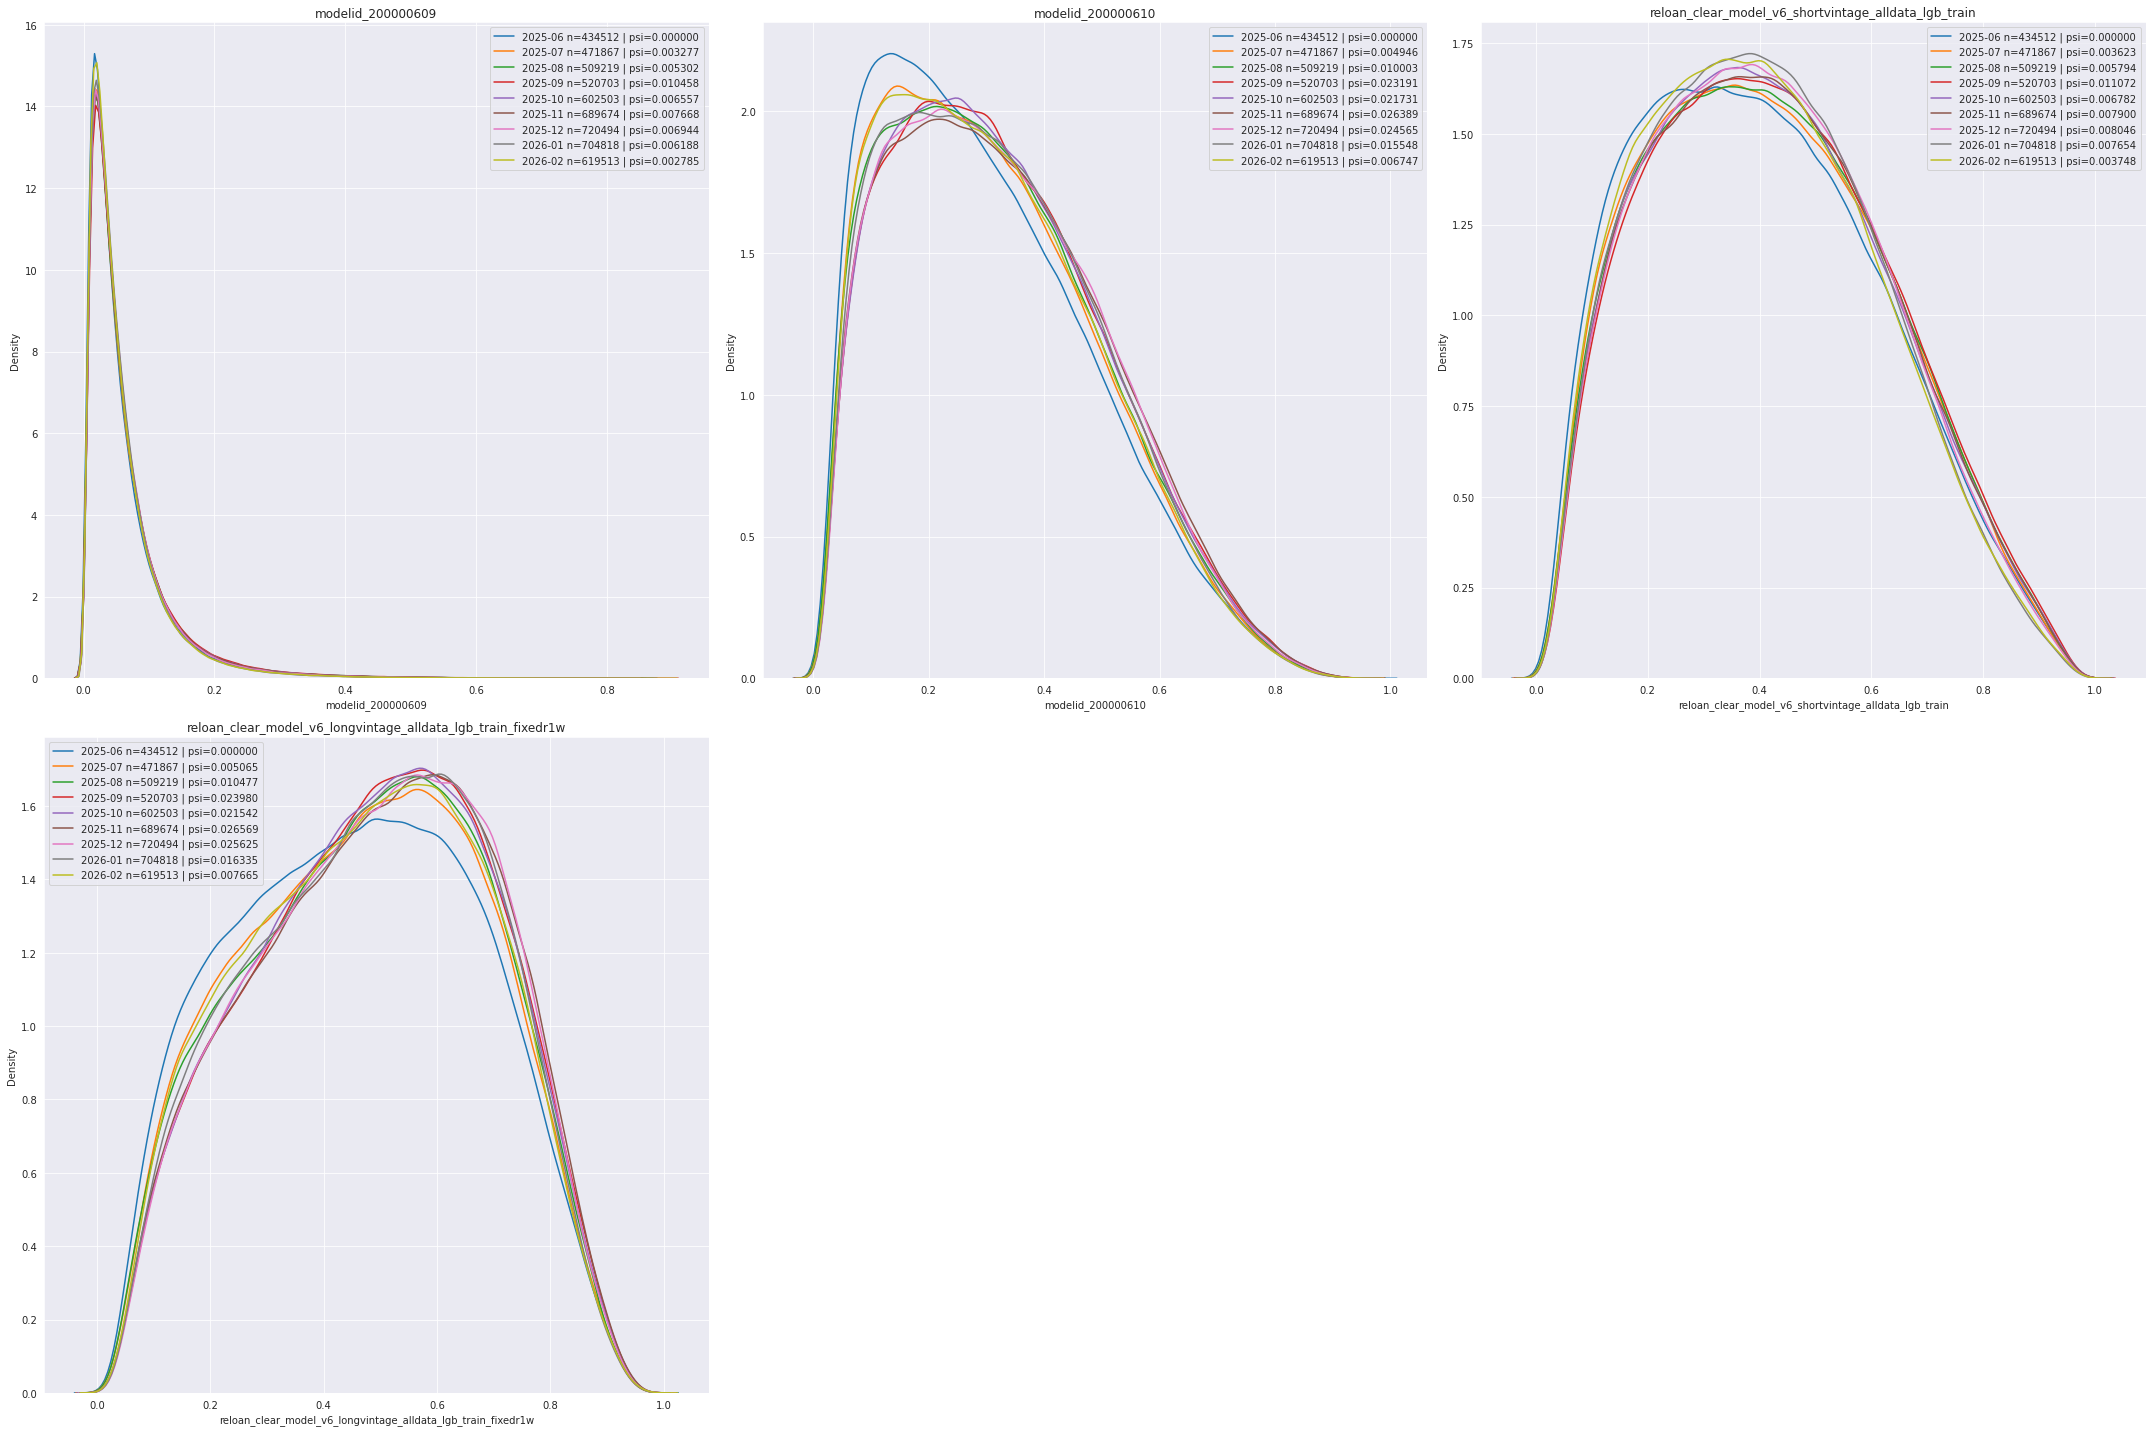


********************************************** 5.2 全量客群模型分布-分bin比例版 ***********************************************************
model : modelid_200000609


,2025-06 一次风控count,2025-07 一次风控count,2025-08 一次风控count,2025-09 一次风控count,2025-10 一次风控count,2025-11 一次风控count,2025-12 一次风控count,2026-01 一次风控count,2026-02 一次风控count,2025-06 一次风控rate,2025-07 一次风控rate,2025-08 一次风控rate,2025-09 一次风控rate,2025-10 一次风控rate,2025-11 一次风控rate,2025-12 一次风控rate,2026-01 一次风控rate,2026-02 一次风控rate
0,43451,41713,43563,40768,48981,55322,58529,58935,55333,0.100000,0.088400,0.085549,0.078294,0.081296,0.080215,0.081235,0.083617,0.089317
1,43451,44208,46638,46282,55210,63097,65358,65257,59143,0.100000,0.093687,0.091587,0.088884,0.091634,0.091488,0.090713,0.092587,0.095467
2,43451,45065,48410,49255,57619,65049,69001,68156,62022,0.100000,0.095504,0.095067,0.094593,0.095633,0.094318,0.095769,0.096700,0.100114
3,43451,47283,50350,51414,60680,68903,72299,72143,63960,0.100000,0.100204,0.098877,0.098740,0.100713,0.099907,0.100346,0.102357,0.103242
4,43451,47095,50613,52606,61864,70091,73307,73725,63863,0.100000,0.099806,0.099393,0.101029,0.102678,0.101629,0.101745,0.104601,0.103086
5,43451,47910,51902,53934,62675,71486,75186,74422,64711,0.100000,0.101533,0.101925,0.103579,0.104024,0.103652,0.104353,0.105590,0.104455
6,43451,48348,53101,54654,63708,73117,77083,76379,64848,0.100000,0.102461,0.104279,0.104962,0.105739,0.106017,0.106986,0.108367,0.104676
7,43451,49310,53982,55722,63311,73232,77879,76258,64884,0.100000,0.104500,0.106009,0.107013,0.105080,0.106184,0.108091,0.108195,0.104734
8,43451,50092,54594,56322,62766,74073,77351,73815,63128,0.100000,0.106157,0.107211,0.108165,0.104175,0.107403,0.107358,0.104729,0.101899
9,43452,50843,56064,59744,65688,75304,74501,65726,57616,0.100002,0.107749,0.110098,0.114737,0.109025,0.109188,0.103403,0.093252,0.093002


model : modelid_200000610


,2025-06 一次风控count,2025-07 一次风控count,2025-08 一次风控count,2025-09 一次风控count,2025-10 一次风控count,2025-11 一次风控count,2025-12 一次风控count,2026-01 一次风控count,2026-02 一次风控count,2025-06 一次风控rate,2025-07 一次风控rate,2025-08 一次风控rate,2025-09 一次风控rate,2025-10 一次风控rate,2025-11 一次风控rate,2025-12 一次风控rate,2026-01 一次风控rate,2026-02 一次风控rate
0,43451,40865,42925,37399,43266,50404,51798,54206,52093,0.100000,0.086603,0.084296,0.071824,0.071810,0.073084,0.071892,0.076908,0.084087
1,43451,43450,44494,42634,49643,56555,59497,61460,56602,0.100000,0.092081,0.087377,0.081878,0.082395,0.082003,0.082578,0.087200,0.091365
2,43451,44944,45719,45714,54143,59976,63782,63541,58388,0.100000,0.095247,0.089783,0.087793,0.089863,0.086963,0.088525,0.090152,0.094248
3,43451,45363,48198,49789,57291,63671,67187,65895,59451,0.100000,0.096135,0.094651,0.095619,0.095088,0.092320,0.093251,0.093492,0.095964
4,43451,46755,50682,52427,61315,67322,71395,69577,61261,0.100000,0.099085,0.099529,0.100685,0.101767,0.097614,0.099092,0.098716,0.098886
5,43451,48799,52820,55480,63269,70462,74192,73111,63733,0.100000,0.103417,0.103727,0.106548,0.105010,0.102167,0.102974,0.103730,0.102876
6,43451,49711,54690,55860,65452,73760,77299,76259,65918,0.100000,0.105350,0.107400,0.107278,0.108633,0.106949,0.107286,0.108197,0.106403
7,43451,50237,55775,58677,67048,77780,80904,79380,66842,0.100000,0.106464,0.109530,0.112688,0.111282,0.112778,0.112290,0.112625,0.107894
8,43451,50792,56267,59746,69217,81944,86803,81938,68129,0.100000,0.107641,0.110497,0.114741,0.114882,0.118816,0.120477,0.116254,0.109972
9,43452,50951,57649,62977,71859,87800,87637,79451,67096,0.100002,0.107977,0.113211,0.120946,0.119267,0.127307,0.121635,0.112726,0.108304


model : reloan_clear_model_v6_shortvintage_alldata_lgb_train


,2025-06 一次风控count,2025-07 一次风控count,2025-08 一次风控count,2025-09 一次风控count,2025-10 一次风控count,2025-11 一次风控count,2025-12 一次风控count,2026-01 一次风控count,2026-02 一次风控count,2025-06 一次风控rate,2025-07 一次风控rate,2025-08 一次风控rate,2025-09 一次风控rate,2025-10 一次风控rate,2025-11 一次风控rate,2025-12 一次风控rate,2026-01 一次风控rate,2026-02 一次风控rate
0,43451,41387,42888,40399,48900,55336,57373,58165,55027,0.100000,0.087709,0.084223,0.077585,0.081161,0.080235,0.079630,0.082525,0.088823
1,43451,43847,46620,45767,54820,62389,64980,64652,59802,0.100000,0.092922,0.091552,0.087895,0.090987,0.090462,0.090188,0.091729,0.096531
2,43451,45350,48179,49097,57240,64892,68920,68532,61378,0.100000,0.096108,0.094614,0.094290,0.095004,0.094091,0.095657,0.097234,0.099075
3,43451,46859,50368,51523,60757,68795,72268,72244,63886,0.100000,0.099306,0.098912,0.098949,0.100841,0.099750,0.100303,0.102500,0.103123
4,43451,47602,51461,53262,62831,70698,75354,74938,65370,0.100000,0.100880,0.101059,0.102289,0.104283,0.102509,0.104587,0.106322,0.105518
5,43451,47896,52026,54053,62939,72208,76328,76063,66095,0.100000,0.101503,0.102168,0.103808,0.104463,0.104699,0.105938,0.107919,0.106689
6,43451,48254,53139,55035,63876,72932,77323,76507,65202,0.100000,0.102262,0.104354,0.105694,0.106018,0.105749,0.107319,0.108549,0.105247
7,43451,49354,53887,55688,63197,73987,78051,76452,64982,0.100000,0.104593,0.105823,0.106948,0.104891,0.107278,0.108330,0.108471,0.104892
8,43451,50609,54763,56736,63135,73990,76974,73319,61747,0.100000,0.107253,0.107543,0.108960,0.104788,0.107283,0.106835,0.104025,0.099670
9,43452,50709,55888,59141,64806,74447,72923,63946,56022,0.100002,0.107465,0.109752,0.113579,0.107561,0.107945,0.101213,0.090727,0.090429


model : reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w


,2025-06 一次风控count,2025-07 一次风控count,2025-08 一次风控count,2025-09 一次风控count,2025-10 一次风控count,2025-11 一次风控count,2025-12 一次风控count,2026-01 一次风控count,2026-02 一次风控count,2025-06 一次风控rate,2025-07 一次风控rate,2025-08 一次风控rate,2025-09 一次风控rate,2025-10 一次风控rate,2025-11 一次风控rate,2025-12 一次风控rate,2026-01 一次风控rate,2026-02 一次风控rate
0,43451,40691,42742,37217,43538,50338,51071,53444,51286,0.100000,0.086234,0.083936,0.071475,0.072262,0.072988,0.070883,0.075827,0.082784
1,43451,43597,44169,42209,49052,55716,58930,60897,56022,0.100000,0.092393,0.086739,0.081062,0.081414,0.080786,0.081791,0.086401,0.090429
2,43451,44444,45409,45569,53809,59843,63714,63562,58155,0.100000,0.094188,0.089174,0.087514,0.089309,0.086770,0.088431,0.090182,0.093872
3,43451,45896,48562,50076,58265,64658,68186,66487,59656,0.100000,0.097265,0.095366,0.096170,0.096705,0.093752,0.094638,0.094332,0.096295
4,43451,46755,50720,52462,61461,67702,71490,70078,61840,0.100000,0.099085,0.099604,0.100752,0.102009,0.098165,0.099224,0.099427,0.099820
5,43451,48566,52890,55146,63114,70256,73828,73164,63563,0.100000,0.102923,0.103865,0.105907,0.104753,0.101868,0.102469,0.103806,0.102602
6,43451,49944,55163,57017,66157,74283,77968,76416,66268,0.100000,0.105843,0.108329,0.109500,0.109804,0.107707,0.108215,0.108419,0.106968
7,43451,50339,55550,58190,66662,77733,80668,79338,67023,0.100000,0.106680,0.109089,0.111753,0.110642,0.112710,0.111962,0.112565,0.108187
8,43451,51001,56546,59640,69001,81513,86655,82081,68295,0.100000,0.108083,0.111045,0.114537,0.114524,0.118191,0.120272,0.116457,0.110240
9,43452,50634,57468,63177,71444,87632,87983,79351,67404,0.100002,0.107306,0.112855,0.121330,0.118579,0.127063,0.122115,0.112584,0.108802




5、交叉评估heatmap
********************************************** 6.1 成功放款客群 逐月长短风险模型heatmap ***********************************************************
成功放款客群：main_model_v6_shortvintage cross main_model_v6_longvintage heatmap
trace month: 2025-10
eval_data shape: (128065, 389)


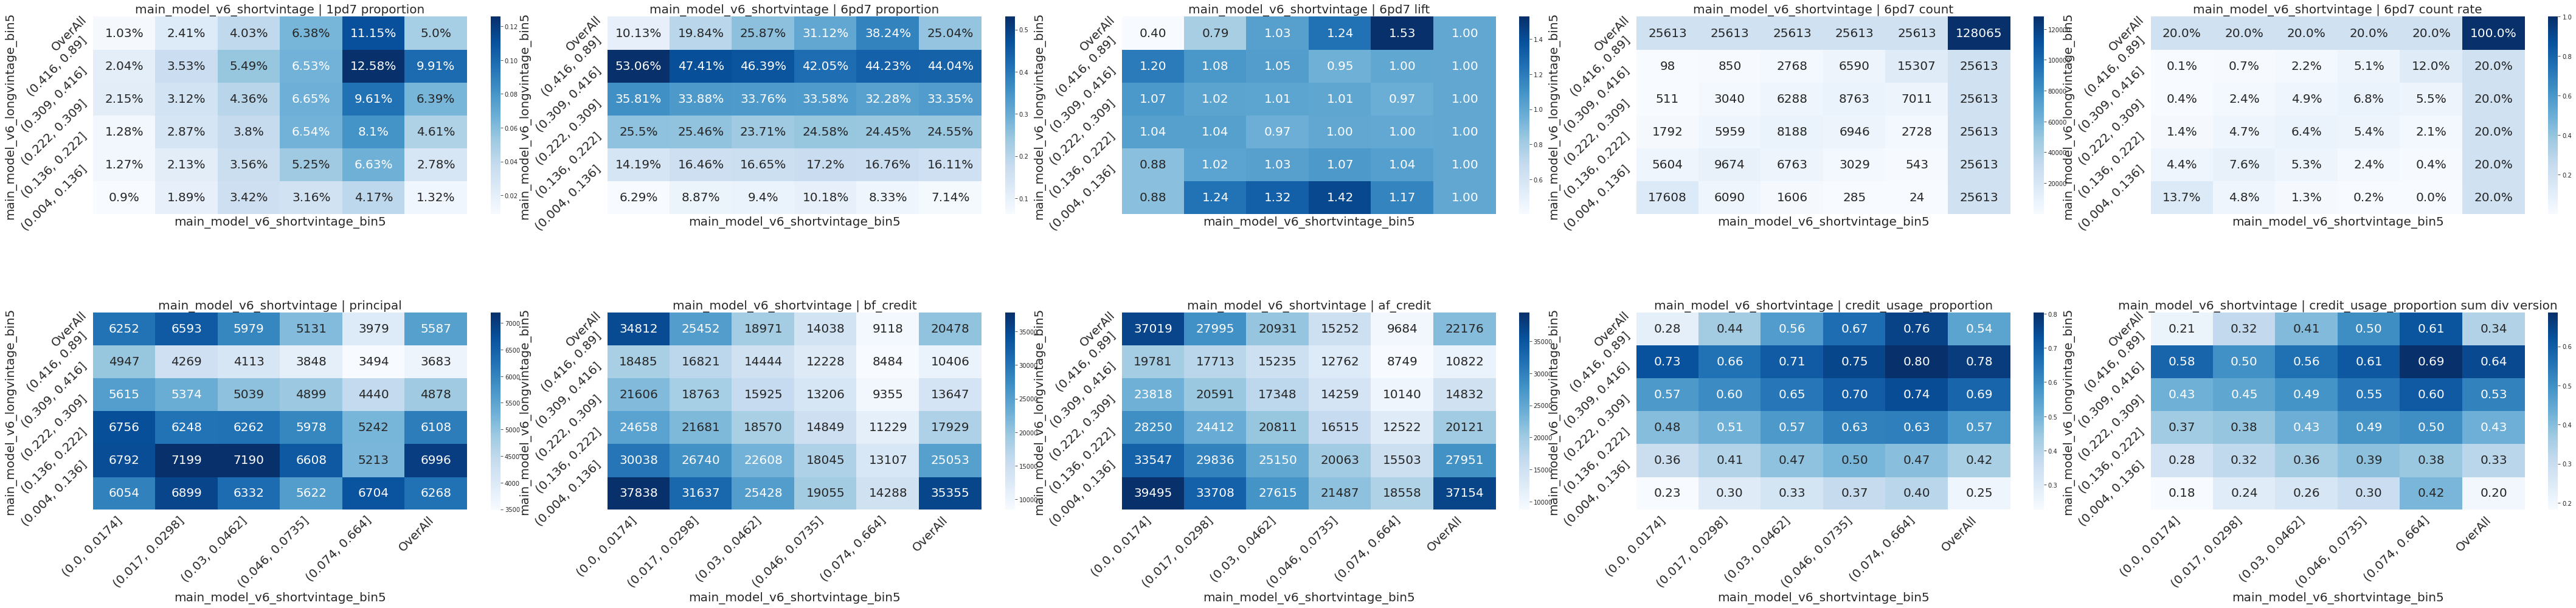



trace month: 2025-11
eval_data shape: (126599, 389)


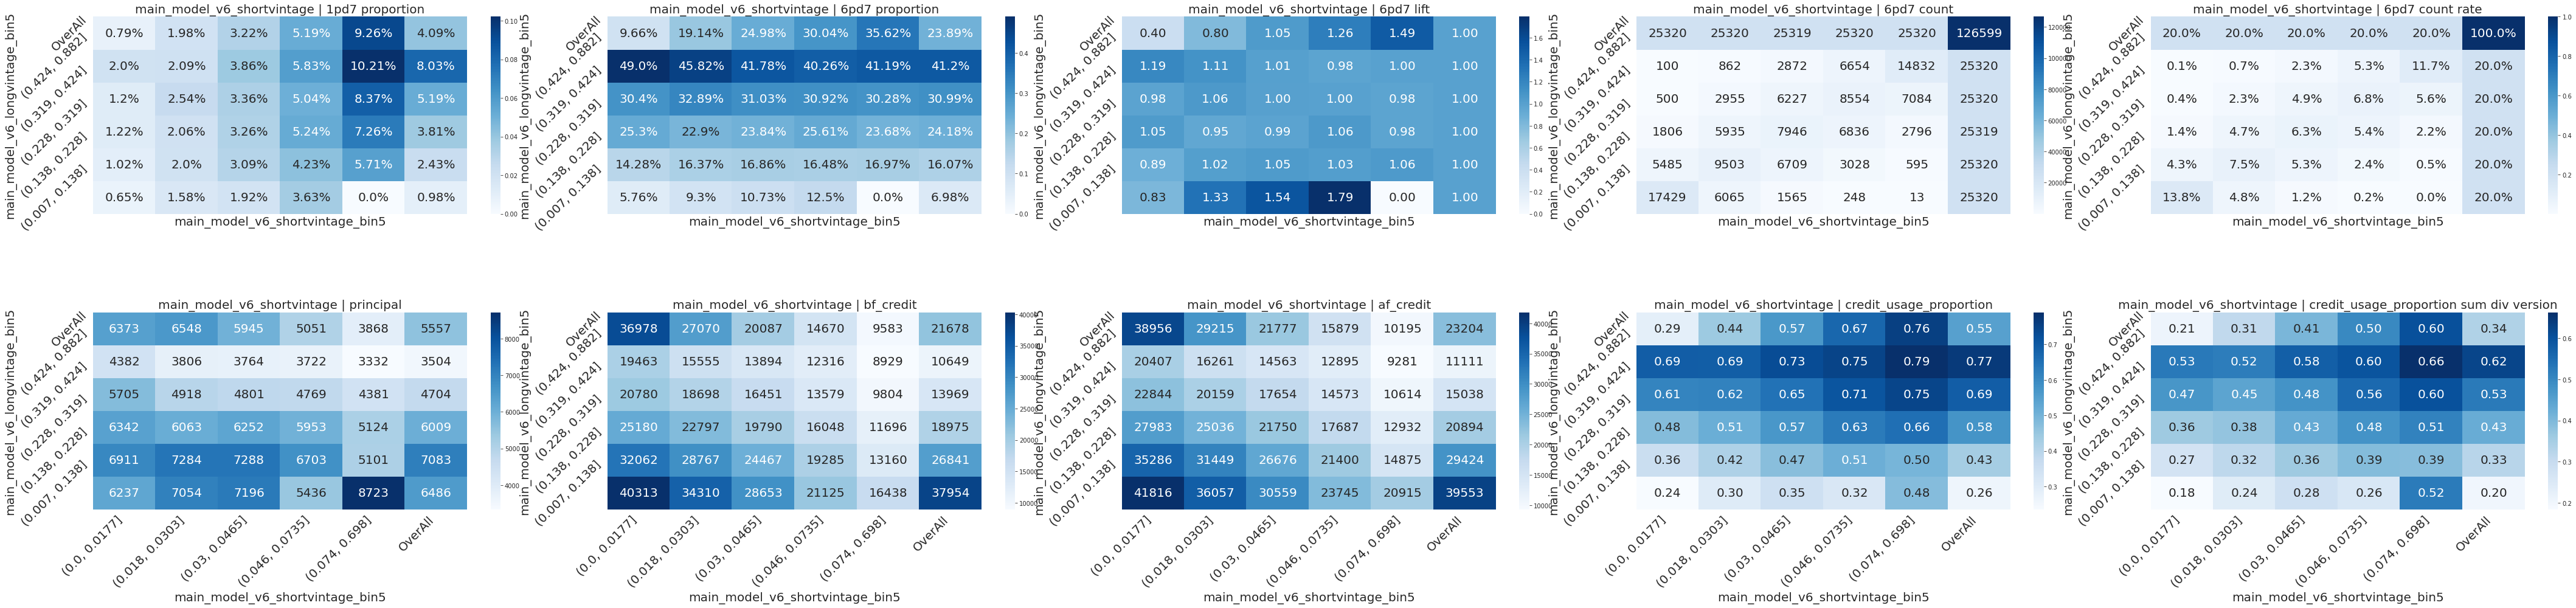



trace month: 2025-12
eval_data shape: (114901, 389)


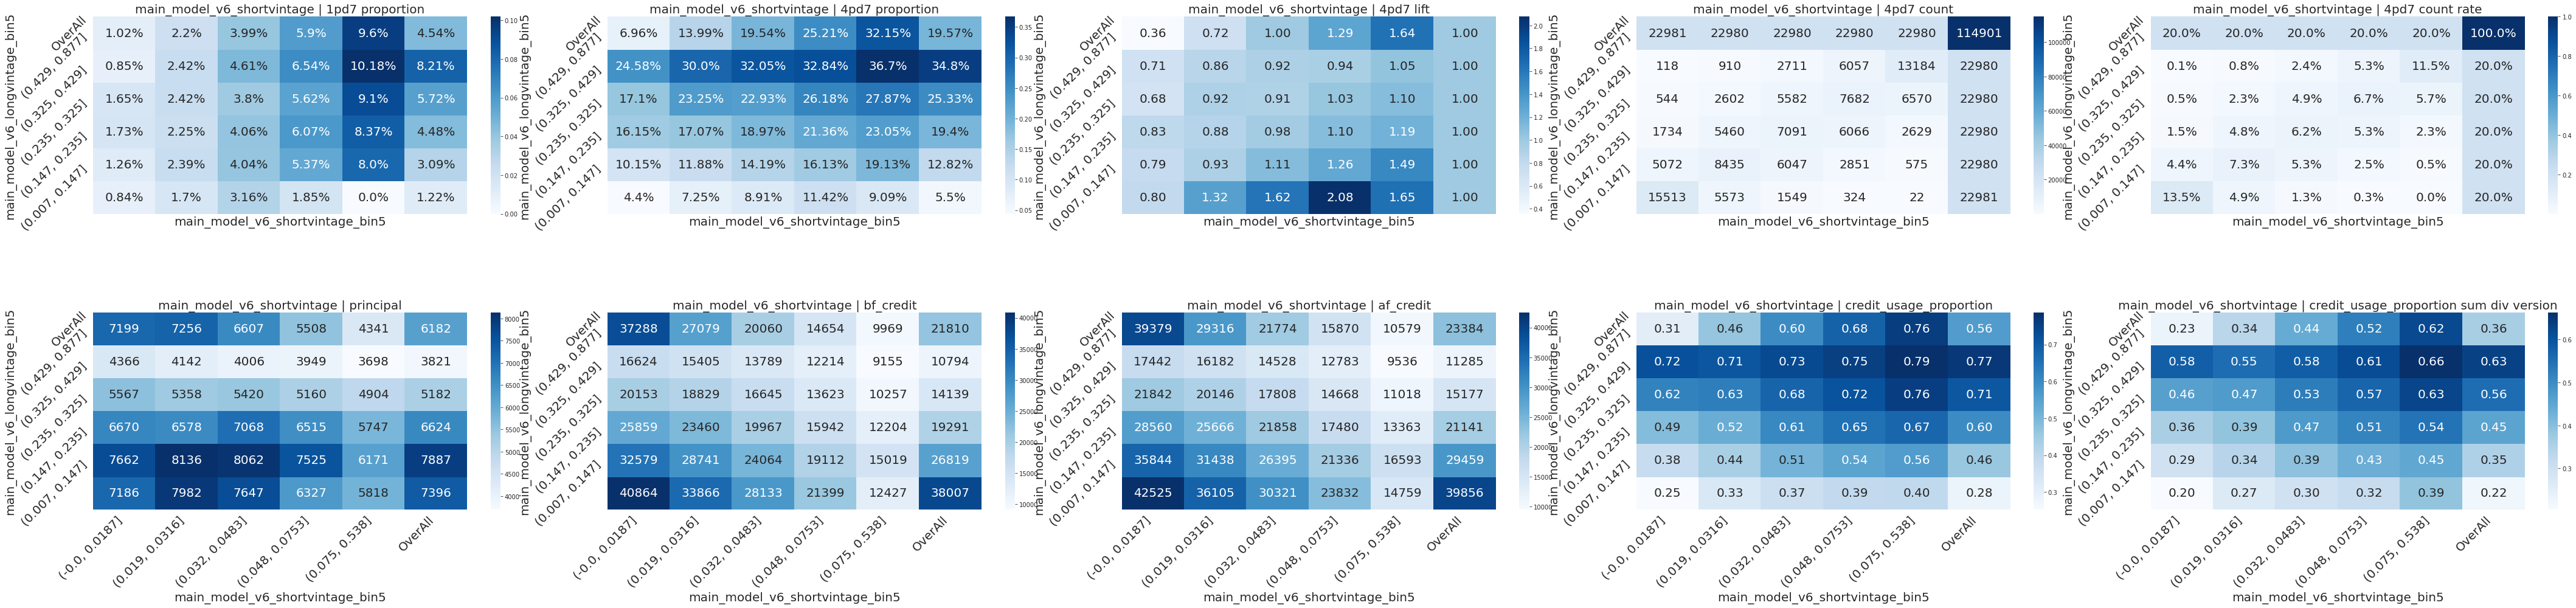



报告产出耗时：35.982947727044426 分钟


In [8]:
# 评估模型list
model_list = ['modelid_200000609',  # 主模型V6-短风险版  线上模型分
             'modelid_200000610',   # 主模型V6-长风险版  线上模型分
              'reloan_clear_model_v6_shortvintage_alldata_lgb_train', # 主模型V6-短风险版 LGB重train版 预估模型分
             'reloan_clear_model_v6_longvintage_alldata_lgb_train_fixedr1w' # 主模型V6-长风险版 LGB重train版 预估模型分
             ]

print('************************************************* 0 评估模型列表 ********************************************************')
print(model_list)

print()
print()


t1 = time.time()

# 1、模型相关性
print('1、模型相关性')
print('************************************************* 1.1 一次风控（全量客群）********************************************************')
display(test_data[model_list].corr())

print('************************************************* 1.2 成功放款客群  *************************************************************')
display(test_data[model_list].corr())

print()
print()

# 2、AUC评估 （风险标签1pd7、4pd7、6pd7）
print('2、AUC')
print('trace_month 时间分组')
print('')
print('********************************************** 2.1 成功放款客群：OOT:本笔label (新增风险)***********************************************************')
for label in ['1pd7','4pd7', '6pd7']:

    print(label)
    df = modelEvaluation.get_auc_groups(
        test_data[
            (test_data[label].notnull())
        ], # 对比样本
        model_list, # 需要对比的模型list
        label, # 计算auc使用的label,
        'trace_month' # 计算AUC的时间分组
    )
    
print()
    
print('********************************************** 2.2 成功放款客群：BOOT: 本笔label (新增风险)***********************************************************')
for label in ['1pd7', '4pd7', '6pd7']:

    print(label)
    df = modelEvaluation.get_auc_groups(
        test_data[
            (test_data[label].notnull())
            & (test_data['boot_main_model_v6'] == 1) # 评估样本中剔除训练集中见过的坏人
        ], # 对比样本
        model_list, # 需要对比的模型list
        label, # 计算auc使用的label,
        'trace_month' # 计算AUC的时间分组
    )
    
print()
print()

# 3、人头逾期和金额逾期曲线
print('3、人头逾期和金额逾期曲线')
print('********************************************** 3.1 本笔订单人头逾期（term1、term4、term6）***********************************************************')

# 注释： '20250601~20260118' 是可看4期风险的时间段，只是作为标题注释，可以自定义
# 1、4、6期是常用风险期数，可以自行设置要看的期数

for i, m in zip([1, 4, 6], ['202506~202602', '202506~202601', '202506~202512']):
    
    # 评估数据集
    eval_data = test_data[(test_data[f'{i}pd7'].notna())
                         & (test_data.modelid_200000609.notna())
                         & (test_data.modelid_200000610.notna())
                         ]
    eval_data['tag'] = 1
    
    # 参数
    term = i             # label期数
    ipd7 = f'{i}pd7'     # 计算AUC的label
    unpaid = f'{i}pd7'   # 逾期曲线分子
    principal = 'tag'    # 逾期曲线分母
    title = f'{i}pd7'    # 标题
    month = f'{m} AllTerms'  # 时间分组名称
    score_list = model_list.copy() # model score_list
    model_name_list =  model_list.copy() # model_name_list
    
    modelEvaluation2.get_cumulative_bad_debt_rate_plot(eval_data, # 评估数据集
                                      term, # label期数
                                      ipd7, # 计算AUC的label
                                      unpaid, # 逾期曲线分子
                                      principal, # 逾期曲线分母
                                      title, # 标题
                                      month, # 月份名称
                                      score_list, # model score_list
                                      model_name_list, # model_name_list
                                      p = 0. # 剔除曲线头部比例
                                     )

print()

print('********************************************** 3.2 本笔订单金额逾期（term1、term4、term6）***********************************************************')

for i, m in zip([1, 4, 6], ['202506~202602', '202506~202601', '202506~202512']):
    
    # 评估数据集
    eval_data = test_data[(test_data[f'{i}pd7'].notna())
                         & (test_data.modelid_200000609.notna())
                         & (test_data.modelid_200000610.notna())
                         ]
    
    # 参数
    term = i             # label期数
    ipd7 = f'{i}pd7'     # 计算AUC的label
    unpaid = f'{i}pd7_unpaid'       # 逾期曲线分子
    principal = 'current_payout_order_principal'    # 逾期曲线分母
    title = f'{i}pd7_unpaid'    # 标题
    month = f'{m} AllTerms' # 时间分组名称
    score_list = model_list.copy() # model score_list
    model_name_list =  model_list.copy() # model_name_list
    
    modelEvaluation2.get_cumulative_bad_debt_rate_plot(eval_data, # 评估数据集
                                      term, # label期数
                                      ipd7, # 计算AUC的label
                                      unpaid, # 逾期曲线分子
                                      principal, # 逾期曲线分母
                                      title, # 标题
                                      month, # 月份名称
                                      score_list, # model score_list
                                      model_name_list, # model_name_list
                                      p = 0. # 剔除曲线头部比例
                                     )
print()
print()


# 4、分bin-风险Lift和基础画像
print('4、分bin-风险Lift和基础画像')
print('********************************************** 4.1 成功放款客群 分bin-风险Lift和基础画像 - 6pd7长期风险标签 ***********************************************************')
# 基础字段统计dict 可自行设置
basic_info = {'trace_id': 'count', # 一次风控traceid
             'current_payout_order_id': 'count' # 成功放款ID
             }
# 画像统计dict 可自行设置
index_dic = {'is_order': 'mean', # 是否下单
            'is_payout': 'mean', # 是否成功放款
             'first_order_credit_usage_rate': 'mean', # 一次风控后首个订单额度使用率
            'bf_credit': 'mean', # 一次风控前授信额度
            'af_credit': 'mean', # 一次风控后授信额度
            'bf_max_overdue_days': 'mean', # 一次风控时，用户历史最大逾期天数
            'bf_loan_times': 'mean', # 一次风控时，用户放款笔数
            'bf_inloan_order_cnt': 'mean', # 一次风控时，用户在贷笔数
            'bf_latest_payout_order_paid_terms': 'mean'  # 一次风控时，用户最近一笔订单已还期数
            }

# 风险标签
label = '6pd7' # 分Bin-lift使用的label，可自行设置

# 调用示例
for model in model_list:
    # 评估数据集获取
    eval_data = test_data[
        (test_data.current_payout_order_id.notna()) # 限制为成功放款客群
                         & (test_data[model].notna())
                         & (test_data[label].notna())][list(basic_info.keys())+[model]+[label] + list(index_dic.keys())]
    # 获取画像计算结果
    result = modelEvaluation2.cal_stats_part(eval_data, # 评估数据集
                            model, # 模型名称
                            basic_info, # 基础字段统计dict
                            label, # 风险标签
                            index_dic, # 画像统计dict
                           q = 10 # 模型分bin数量
                           )
    print(model)
    # 标准化输出
    display(result.style.format({
        'num_ratio': '{:.3f}',  # 默认输出 订单占比
        "good_num":'{:.0f}',    # 默认输出 好样本笔数
        "bad_num":'{:.0f}',     # 默认输出 坏样本笔数
        'bad_ratio': '{:.4f}',  # 默认输出 坏样本比例
        'good_cumsum': '{:.4f}', # 默认输出 好样本累积占比
        'bad_cumsum': '{:.4f}', # 默认输出 坏样本累积占比
        'ks': '{:.4f}',         # 默认输出 风险标签KS
        'acc_auc': '{:.4f}',    # 默认输出 风险标签累积AUC
        'bin_auc': '{:.4f}',    # 默认输出 风险标签分bin-AUC
        'bin_lift': '{:.3f}',   # 默认输出 风险标签分bin-lift
        'trace_id': '{:.0f}',   # 分bin一次风控样本量
        'current_payout_order_id': '{:.0f}', # 分bin成功放款样本量
        'bf_credit': '{:.0f}',   # 分bin风控前授信额度
        'af_credit': '{:.0f}',   # 分bin风控后授信额度
        'is_order': '{:.4f}',    # 分bin下单率
        'is_payout': '{:.4f}',   # 分bin成功放款率
        'first_order_credit_usage_rate': '{:.3f}', # 分bin一次风控后首个订单额度使用率
        'bf_max_overdue_days': '{:.4f}', # 分bin一次风控时用户历史最大逾期天数
        'bf_loan_times': '{:.4f}',   # 分bin一次风控时用户历史放款笔数
        'bf_inloan_order_cnt': '{:.4f}', # 分bin一次风控时用户在贷笔数
        'bf_latest_payout_order_paid_terms': '{:.4f}', # 分bin一次风控时用户最近一笔订单成功还款期数
    }).bar(subset=['bin_lift'], color='#8B0000', vmin=0)) 
    
    
    
print()
print()

# 5、模型分布
print('5、模型分布')
print('********************************************** 5.1 全量客群模型分布-图示版 ***********************************************************')

time_group = 'trace_month' # 模型分布时间分组
start_time_group = '2025-06' # 初始时间分组，以初始分组计算后续分组PSI，统计分布稳定性
time_group_list = sorted(set(test_data[time_group].tolist())) # 模型分布时间分组list

modelEvaluation2.get_model_distribution(test_data, # 获取评估数据
                           time_group, # 模型分布时间分组
                           start_time_group, # 初始时间分组，以初始分组计算后续分组PSI，统计分布稳定性
                           model_list, # 模型list
                           time_group_list, # 模型分布时间分组list
                           n_cols = 3  # 默认每行3列
                          )
print()
print('********************************************** 5.2 全量客群模型分布-分bin比例版 ***********************************************************')

for model in model_list:
    print(f'model : {model}')
    time_group = 'trace_month' # 模型分布时间分组
    start_time_group = '2025-06' # 初始时间分组，以初始分组计算后续分组PSI，统计分布稳定性
    time_group_list = sorted(set(test_data[time_group].tolist())) # 模型分布时间分组list
    
    modelEvaluation2.distribution_bin(test_data, # 获取评估数据
                    time_group, # 模型分布时间分组
                    start_time_group, # 初始时间分组，以初始分组计算后续分组PSI，统计分布稳定性
                    model, # 模型分
                    time_group_list, # 模型分布时间分组list
                     q = 10 # 模型分bin数量
                    )
    
print()
print()

# 6、交叉评估heatmap

# 使用说明：需要指定交叉的2个模型

print('5、交叉评估heatmap')
print('********************************************** 6.1 成功放款客群 逐月长短风险模型heatmap ***********************************************************')
print('成功放款客群：main_model_v6_shortvintage cross main_model_v6_longvintage heatmap')

for month, long_vintage_index in zip(['2025-10', '2025-11', '2025-12'], [6, 6, 4]):
    
    print(f'trace month: {month}')
    
    # 参数设置
    x_score = 'modelid_200000609'
    y_score = 'modelid_200000610'
    x_bins = 'main_model_v6_shortvintage_bin5' # 自定义名字，作为横轴名称
    y_bins = 'main_model_v6_longvintage_bin5' # 自定义名字，作为纵轴名称
    maximum_observable_term_risk_label = f'{long_vintage_index}pd7'
    term1_risk_label = '1pd7'
    pred = 'main_model_v6_shortvintage' # 自定义名字，作为标题名称
    credit_usage_rate = 'first_payout_credit_usage_rate'
    order_principal = 'first_payout_order_principal'
    order_credit = 'first_payout_order_credit'
    bf_credit = 'bf_credit'
    af_credit = 'af_credit'
    
    # 获取评估数据集
    eval_data = test_data[(test_data[term1_risk_label].notna())
                    & (test_data.trace_month.isin([month]))  # 选择评估月份
                    & (test_data.current_payout_order_id.notna()) # 限制为成功放款样本
                         & (test_data[maximum_observable_term_risk_label].notna())
                         ]
    print(f'eval_data shape: {eval_data.shape}')
    
    modelEvaluation2.cross_heatmap(eval_data,  # heatmap data
                  x_score, # 横轴模型分名称
                  y_score, # 纵轴模型分名称
                  x_bins, # 横轴模型分bins名称，作为横轴名称
                  y_bins, # 纵轴模型分bins名称，作为纵轴名称
                  maximum_observable_term_risk_label, # 时间分组内最大可看期数风险标签
                  term1_risk_label, # 时间分组内1期数风险标签
                  pred, # 标题模型名称
                  credit_usage_rate, # 额度使用率
                  order_principal, # 借款金额
                  order_credit, # 下单时可借金额
                  bf_credit, # 风控前授信额度
                  af_credit, # 风控后授信额度
                  bins = 5# 默认模型分5bin交叉
                 )
    
    print()
    print()

    
t2 = time.time()
print(f'报告产出耗时：{(t2 - t1)/60} 分钟')